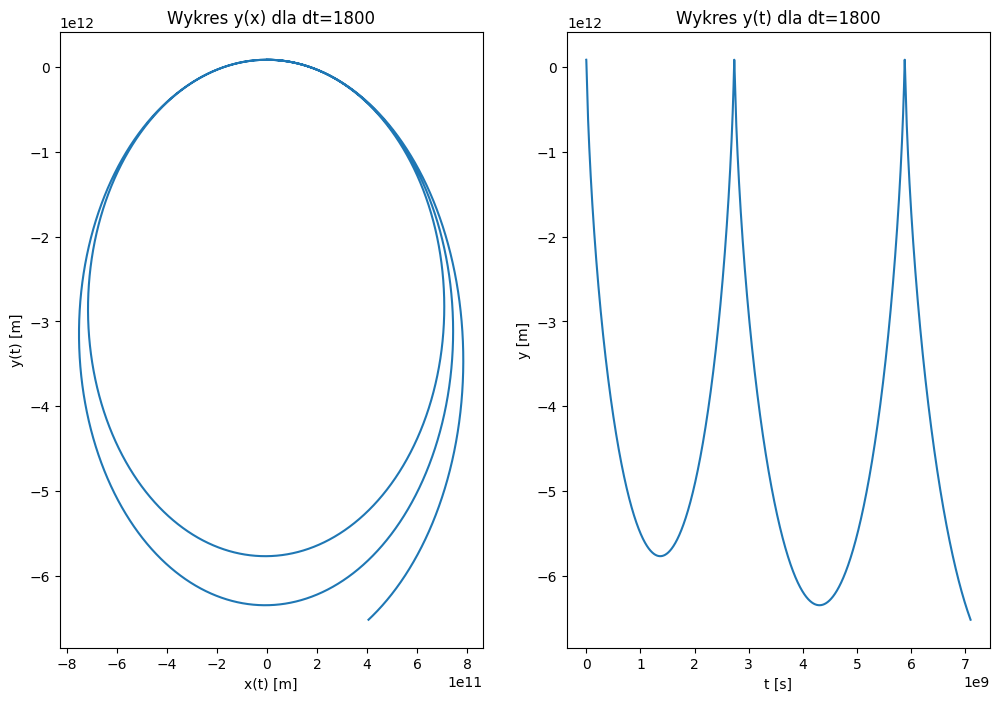

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
x0=(0,0.586*149597870700)
v0=(54600,0)
dt=1800
t_zakres=[0,225*365*24*3600]
def symuluj_ruch(t,dt,x0,v0):
  M=1.989*(10**30)
  G=6.6741*(10**(-11))
  t=np.arange(t[0],t[1]+dt,dt)
  kroki=len(t)
  x_tab=np.zeros((kroki,2))
  v_tab=np.zeros((kroki,2))
  x_tab[0,0],x_tab[0,1],v_tab[0,0],v_tab[0,1]=x0[0],x0[1],v0[0],v0[1]
  for n in range(1, kroki):
    force=-G*M/((x_tab[n-1,0]**2+x_tab[n-1,1]**2))**(3/2)
    x_tab[n,0]=x_tab[n-1,0]+v_tab[n-1,0]*dt
    x_tab[n,1]=x_tab[n-1,1]+v_tab[n-1,1]*dt
    v_tab[n,0]=v_tab[n-1,0]+force*x_tab[n-1,0]*dt
    v_tab[n,1]=v_tab[n-1,1]+force*x_tab[n-1,1]*dt
  return x_tab,v_tab,t
x_tab,v_tab,t=symuluj_ruch(t_zakres,dt,x0,v0)
plt.figure(figsize=(12,8))
plt.subplot(1,2,1)
plt.plot(x_tab[:,0], x_tab[:,1])
plt.title(f"Wykres y(x) dla dt={dt}")
plt.xlabel("x(t) [m]")
plt.ylabel("y(t) [m]")
plt.subplot(1,2,2)
plt.plot(t, x_tab[:,1])
plt.title(f"Wykres y(t) dla dt={dt}")
plt.xlabel("t [s]")
plt.ylabel("y [m]")
plt.show()


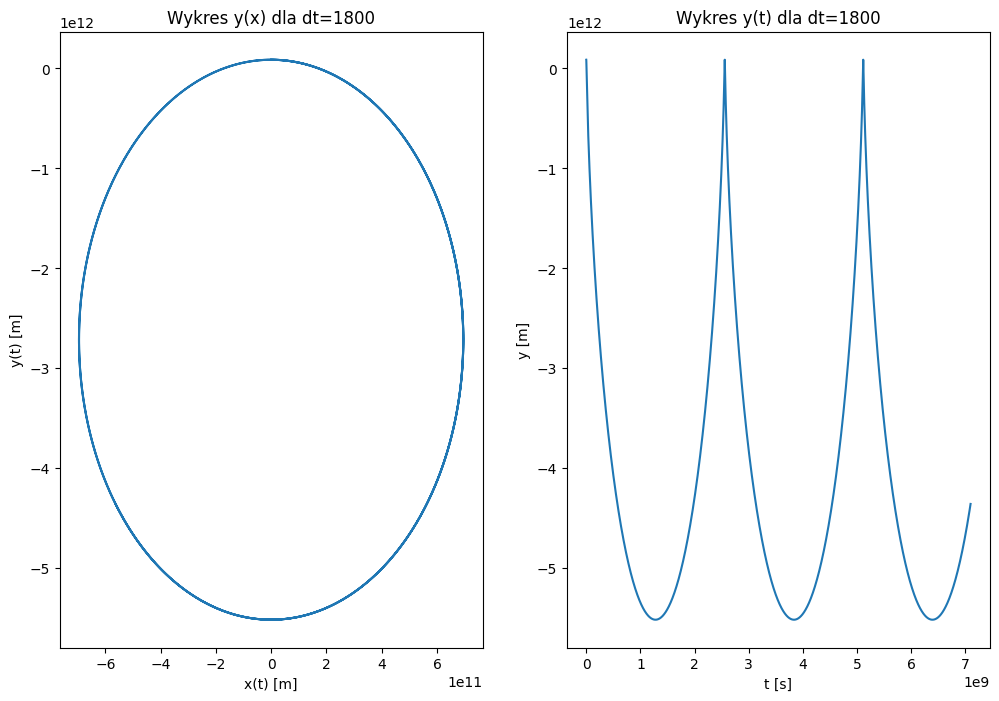

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
x0=(0,0.586*149597870700)
v0=(54600,0)
dt=1800
t_zakres=[0,225*365*24*3600]
def f(u):
  M=1.989*(10**30)
  G=6.6741*(10**(-11))
  vx=u[2]
  vy=u[3]
  ax=-G*M/((u[0]**2+u[1]**2))**(3/2)*u[0]
  ay=-G*M/((u[0]**2+u[1]**2))**(3/2)*u[1]
  return np.array([vx,vy,ax,ay])
def metoda_RK4(t,dt,x0,v0):
  M=1.989*(10**30)
  G=6.6741*(10**(-11))
  t=np.arange(t[0],t[1]+dt,dt)
  kroki=len(t)
  u=np.zeros((kroki,4))
  u[0]=[x0[0],x0[1],v0[0],v0[1]]
  for n in range(1, kroki):
    u_prev=u[n-1]
    k1=f(u_prev)
    k2=f(u_prev+k1*dt/2)
    k3=f(u_prev+k2*dt/2)
    k4=f(u_prev+k3*dt)
    u[n]=u_prev+dt/6*(k1+2*k2+2*k3+k4)
  return u[:,0],u[:,1],t
x_RK4,y_RK4,t=metoda_RK4(t_zakres,dt,x0,v0)
plt.figure(figsize=(12,8))
plt.subplot(1,2,1)
plt.plot(x_RK4, y_RK4)
plt.title(f"Wykres y(x) dla dt={dt}")
plt.xlabel("x(t) [m]")
plt.ylabel("y(t) [m]")
plt.subplot(1,2,2)
plt.plot(t, y_RK4)
plt.title(f"Wykres y(t) dla dt={dt}")
plt.xlabel("t [s]")
plt.ylabel("y [m]")
plt.show()

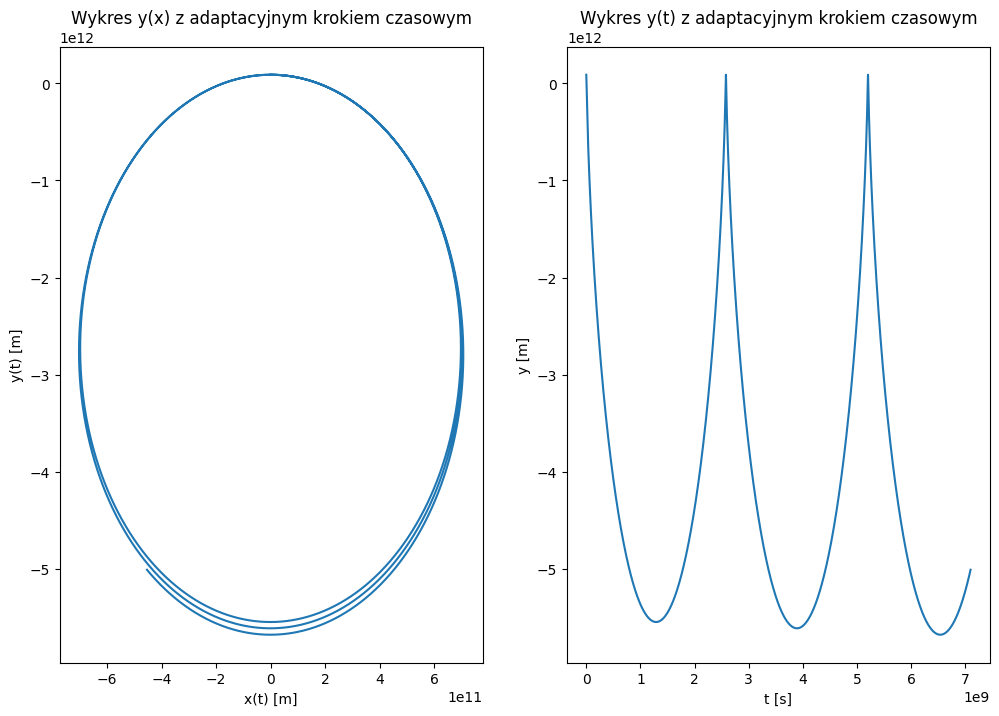

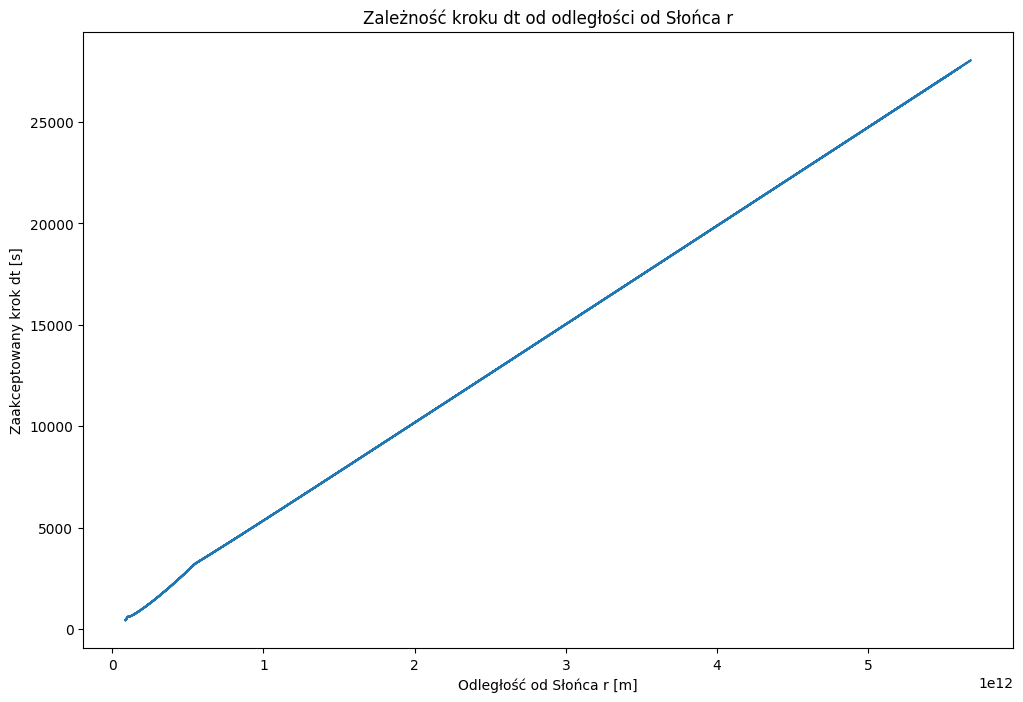

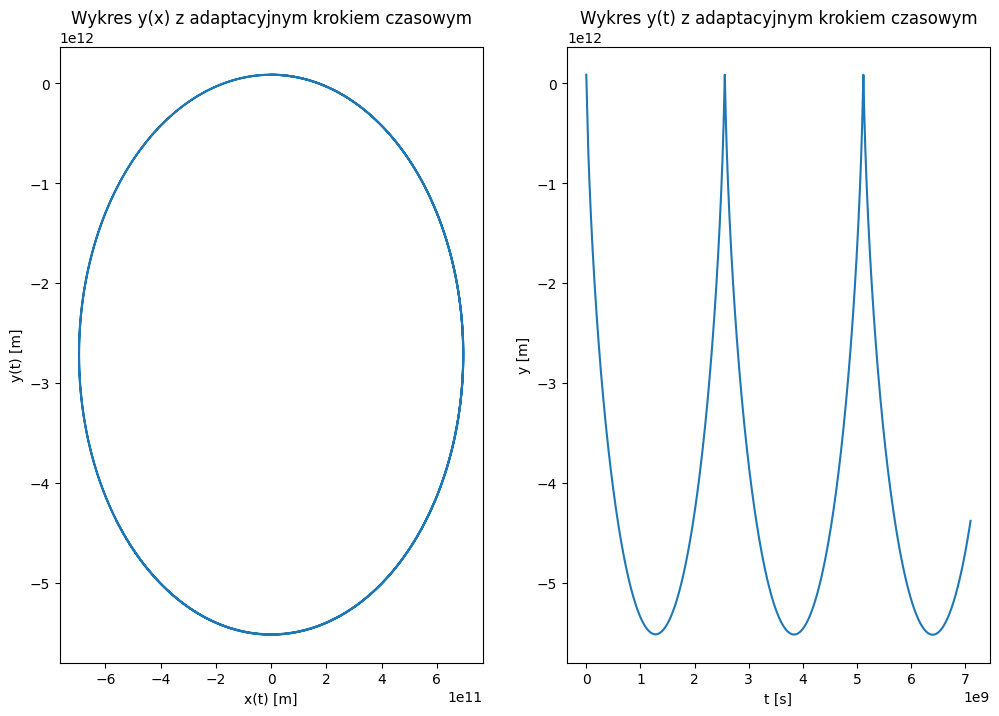

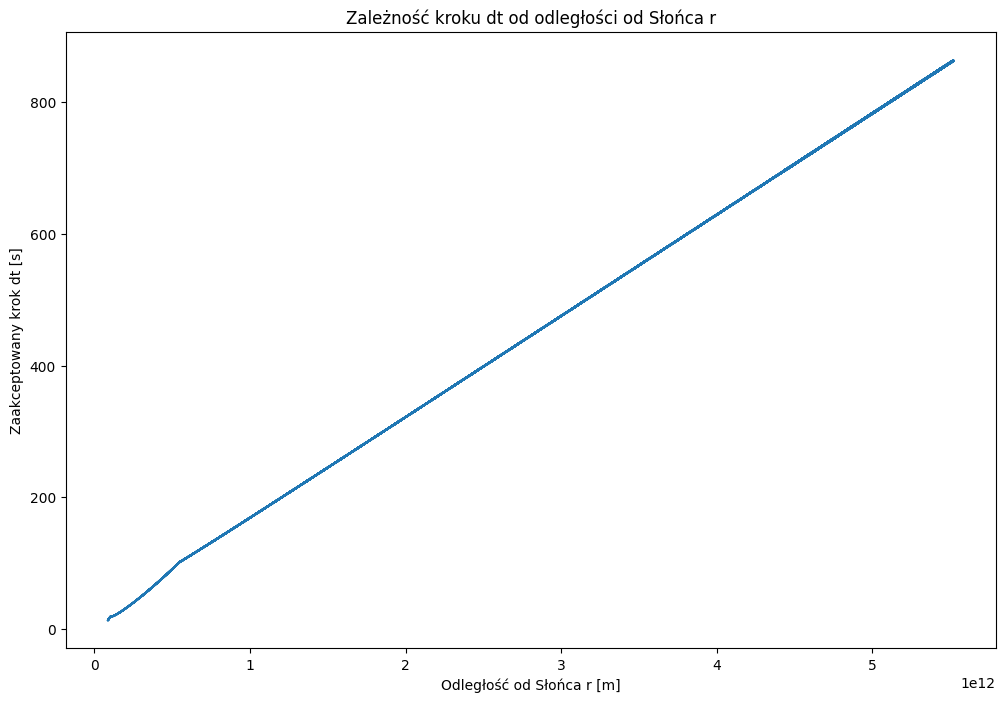

In [1]:
import matplotlib.pyplot as plt
import numpy as np
x0=(0,0.586*149597870700)
v0=(54600,0)
dt=3600
t_zakres=[0,225*365*24*3600]
tol=[1000,1]
def pojedynczy_euler(u,dt):
  u_nowe=np.zeros(4)
  M=1.989*(10**30)
  G=6.6741*(10**(-11))
  force=-G*M/((u[0]**2+u[1]**2))**(3/2)
  u_nowe[0]=u[0]+u[2]*dt
  u_nowe[1]=u[1]+u[3]*dt
  u_nowe[2]=u[2]+force*u[0]*dt
  u_nowe[3]=u[3]+force*u[1]*dt
  return u_nowe
def symuluj_ruch(t_zakres,dt,x0,v0,tol):
  u=np.array([x0[0],x0[1],v0[0],v0[1]])
  t_c=[]
  polozenie=[]
  kroki=[]
  t=t_zakres[0]
  while t<=t_zakres[1]:
    u_dt=pojedynczy_euler(u,dt)
    u_1k=pojedynczy_euler(u,dt/2)
    u_2k=pojedynczy_euler(u_1k,dt/2)
    epsilon=np.max(np.abs(u_2k[:2]-u_dt[:2]))
    if epsilon<tol:
      u=u_2k
      t+=dt
      t_c.append(t)
      polozenie.append(u.copy())
      kroki.append(dt)
    dt=0.9*dt*(tol/epsilon)**0.5
  return np.array(polozenie),np.array(t_c),np.array(kroki)
for tol_val in tol:
  u,t,lista_krokow=symuluj_ruch(t_zakres,dt,x0,v0,tol_val)
  plt.figure(figsize=(12,8))
  plt.subplot(1,2,1)
  plt.plot(u[:,0],u[:,1])
  plt.title(f"Wykres y(x) z adaptacyjnym krokiem czasowym")
  plt.xlabel("x(t) [m]")
  plt.ylabel("y(t) [m]")
  plt.subplot(1,2,2)
  plt.plot(t,u[:,1])
  plt.title(f"Wykres y(t) z adaptacyjnym krokiem czasowym")
  plt.xlabel("t [s]")
  plt.ylabel("y [m]")
  r=(u[:,0]**2+u[:,1]**2)**(1/2)
  plt.show()
  plt.figure(figsize=(12,8))
  plt.plot(r,lista_krokow)
  plt.title("Zależność kroku dt od odległości od Słońca r")
  plt.xlabel("Odległość od Słońca r [m]")
  plt.ylabel("Zaakceptowany krok dt [s]")
  plt.show()


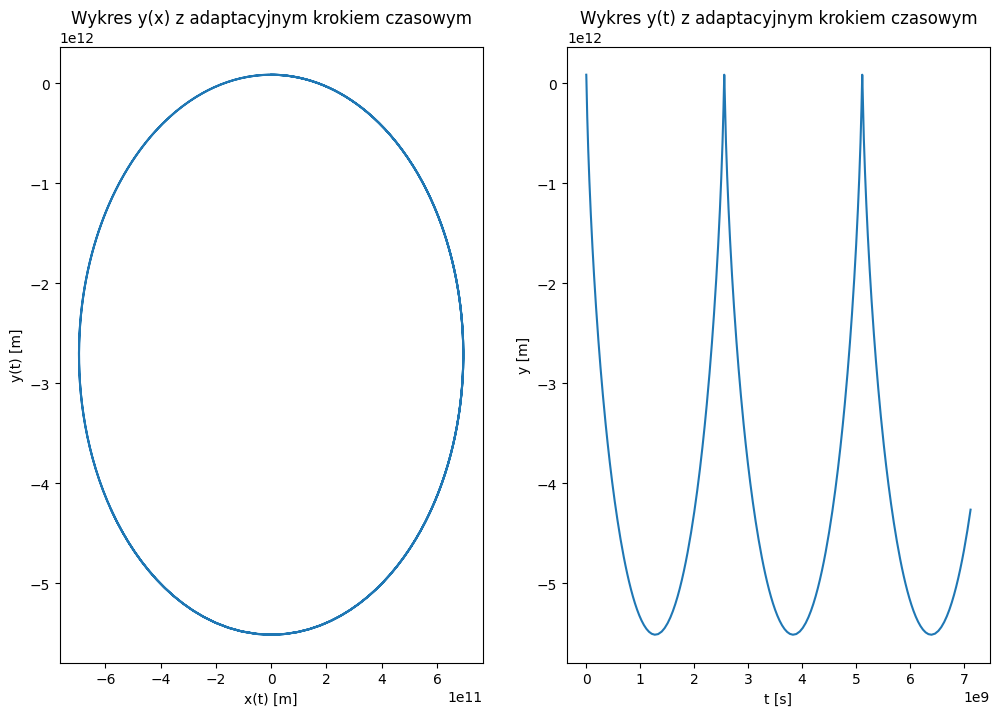

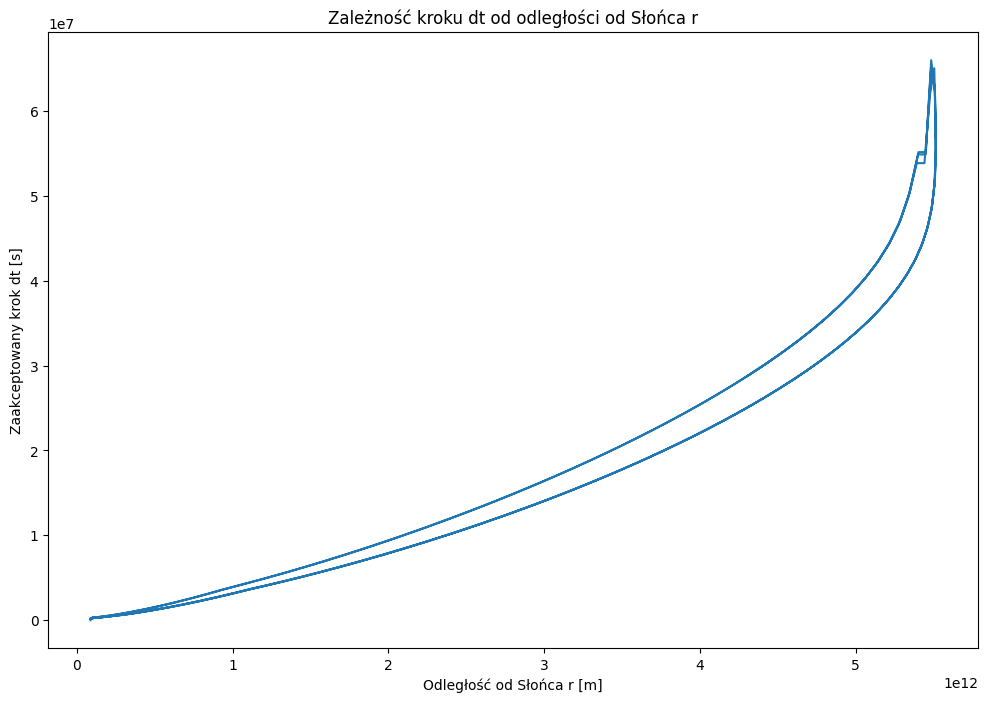

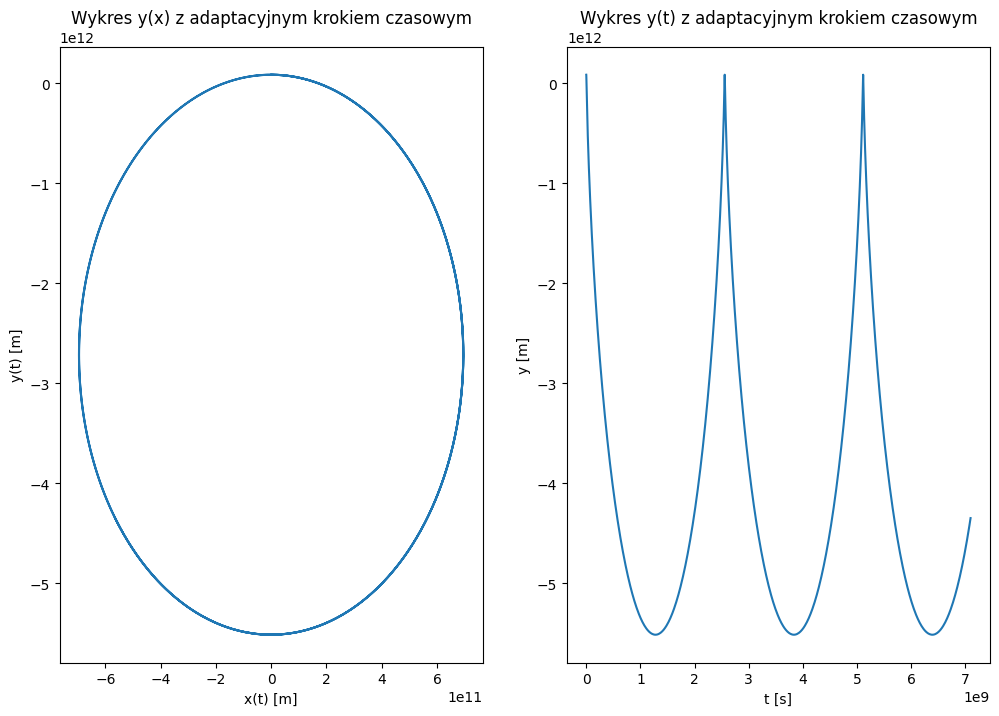

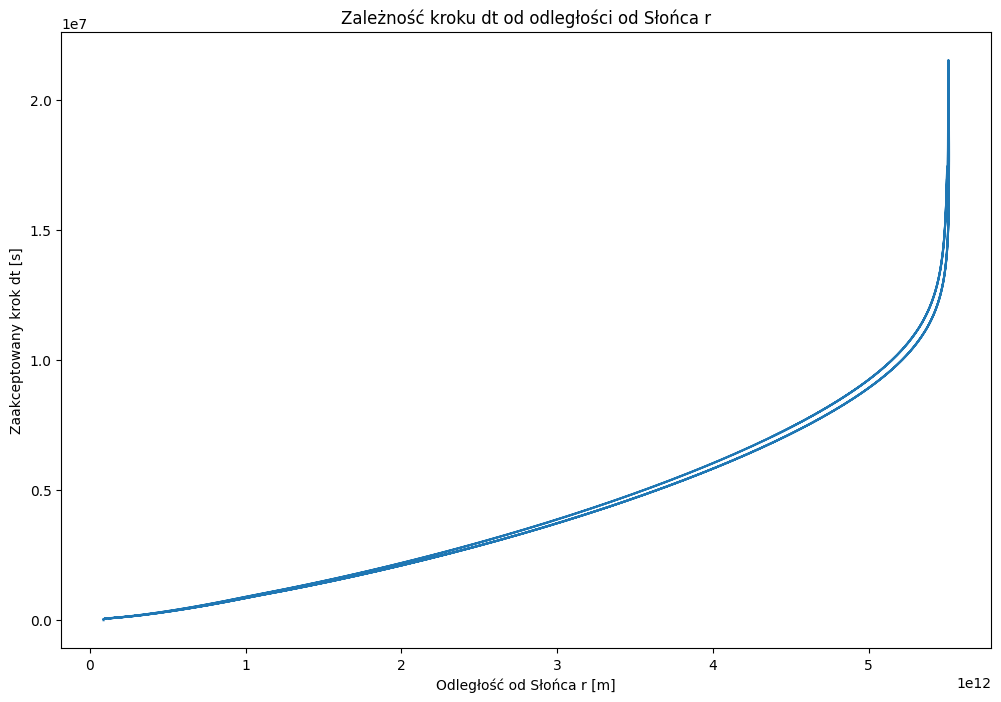

In [2]:
import numpy as np
import matplotlib.pyplot as plt

x0=(0,0.586*149597870700)
v0=(54600,0)
dt=3600
t_zakres=[0,225*365*24*3600]
tol=[1000,1]
def f(u):
  M=1.989*(10**30)
  G=6.6741*(10**(-11))
  vx=u[2]
  vy=u[3]
  ax=-G*M/((u[0]**2+u[1]**2))**(3/2)*u[0]
  ay=-G*M/((u[0]**2+u[1]**2))**(3/2)*u[1]
  return np.array([vx,vy,ax,ay])
def pojedynczy_RK4(u,dt):
  k1=f(u)
  k2=f(u+k1*dt/2)
  k3=f(u+k2*dt/2)
  k4=f(u+k3*dt)
  return u+dt/6*(k1+2*k2+2*k3+k4)
def symuluj_adpRK4(t_zakres,dt,x0,v0,tol):
  u=np.array([x0[0],x0[1],v0[0],v0[1]])
  t_c=[]
  polozenie=[]
  kroki=[]
  t=t_zakres[0]
  while t<=t_zakres[1]:
    u_dt=pojedynczy_RK4(u,dt)
    u_1k=pojedynczy_RK4(u,dt/2)
    u_2k=pojedynczy_RK4(u_1k,dt/2)
    epsilon=np.max(np.abs((u_2k[:2]-u_dt[:2])/15))
    if epsilon<tol:
      u=u_2k
      t+=dt
      t_c.append(t)
      polozenie.append(u.copy())
      kroki.append(dt)
    dt=0.9*dt*(tol/epsilon)**0.2
  return np.array(polozenie),np.array(t_c),np.array(kroki)
for tol_val in tol:
  u,t,lista_krokow=symuluj_adpRK4(t_zakres,dt,x0,v0,tol_val)
  plt.figure(figsize=(12,8))
  plt.subplot(1,2,1)
  plt.plot(u[:,0],u[:,1])
  plt.title(f"Wykres y(x) z adaptacyjnym krokiem czasowym")
  plt.xlabel("x(t) [m]")
  plt.ylabel("y(t) [m]")
  plt.subplot(1,2,2)
  plt.plot(t,u[:,1])
  plt.title(f"Wykres y(t) z adaptacyjnym krokiem czasowym")
  plt.xlabel("t [s]")
  plt.ylabel("y [m]")
  r=(u[:,0]**2+u[:,1]**2)**(1/2)
  plt.show()
  plt.figure(figsize=(12,8))
  plt.plot(r,lista_krokow)
  plt.title("Zależność kroku dt od odległości od Słońca r")
  plt.xlabel("Odległość od Słońca r [m]")
  plt.ylabel("Zaakceptowany krok dt [s]")
  plt.show()